<a href="https://colab.research.google.com/github/click2shivesh/shivesh-uta-aiml-py/blob/main/Shivesh_HelmNet_Full_Code_UPDATED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 47.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 132.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.5/406.5 kB 12.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 96.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import math

# TensorFlow / Keras
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    recall_score, precision_score, f1_score
)

# Display settings
pd.set_option("display.max_columns", None)
warnings = __import__("warnings")
warnings.filterwarnings("ignore")


In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [8]:
from google.colab import drive
drive.mount('/content/drive')
image_candidates = ["/content/drive/MyDrive/AIML-UTA-PY/images.npy", "images.npy"]
label_candidates = ["/content/drive/MyDrive/AIML-UTA-PY/labels.csv", "labels.csv"]

image_path = next((p for p in image_candidates if os.path.exists(p)), None)
label_path = next((p for p in label_candidates if os.path.exists(p)), None)

if image_path is None or label_path is None:
    raise FileNotFoundError(
        "Could not find images.npy and/or labels.csv. "
        "Upload both files to the Colab session before running this cell."
    )

images = np.load(image_path)
labels = pd.read_csv(label_path)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Image dtype  :", images.dtype)
print("Pixel range  :", images.min(), "to", images.max())
print("\nLabel counts:")
print(labels["label"].value_counts().sort_index())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images shape : (4125, 200, 200, 3)
Labels shape : (4125, 1)
Image dtype  : uint8
Pixel range  : 0 to 255

Label counts:
label
0     964
1    3161
Name: count, dtype: int64


### Data Overview — Observations

- The dataset contains **4,125 RGB images**, where each image has a resolution of **200 × 200 pixels with 3 colour channels**.
- The number of labels matches the number of images, confirming that each image has a corresponding target class.
- The target variable contains two classes:
  - **0 – Without Helmet**
  - **1 – With Helmet**
- The images are stored using pixel values in the standard **0–255 range** before normalization.
- The dataset is sufficiently large to build a CNN baseline and compare it with transfer-learning approaches using VGG-16.
- Since this is a workplace-safety classification problem, class distribution and class-specific predictive performance are particularly important and are examined further during EDA.

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

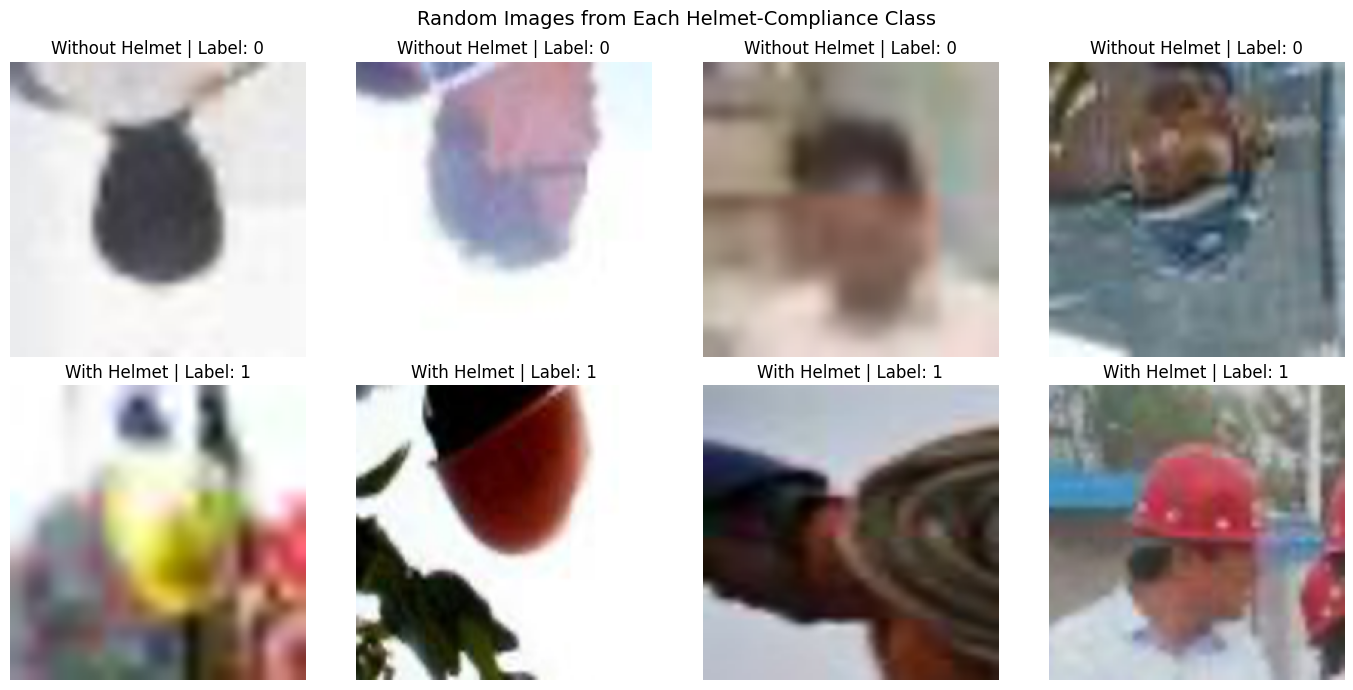

In [9]:
# Plot multiple random examples from both classes.
label_names = {0: "Without Helmet", 1: "With Helmet"}
y_all = labels["label"].astype(int)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_id in enumerate([0, 1]):
    class_indices = np.where(y_all.to_numpy() == class_id)[0]
    chosen = np.random.choice(class_indices, size=4, replace=False)

    for col, idx in enumerate(chosen):
        axes[row, col].imshow(images[idx])
        axes[row, col].set_title(f"{label_names[class_id]} | Label: {class_id}")
        axes[row, col].axis("off")

plt.suptitle("Random Images from Each Helmet-Compliance Class", fontsize=14)
plt.tight_layout()
plt.show()


### Random Image Observations

- The randomly displayed images confirm that both **With Helmet** and **Without Helmet** classes contain realistic workplace images rather than highly uniform studio images.
- Workers appear under different backgrounds, positions, head orientations, camera viewpoints and environmental conditions.
- Helmet appearance also varies, which makes the classification problem more representative of a real safety-monitoring scenario.
- These visual differences mean that the model needs to learn more than a single simple image pattern and should generalize across variations in position, scale and appearance.
- The displayed class labels correctly correspond to the visual examples, indicating that the image and label arrays are aligned.

## Checking for class imbalance


,Class,Count,Percentage
label,,,
0,Without Helmet,964,23.37
1,With Helmet,3161,76.63


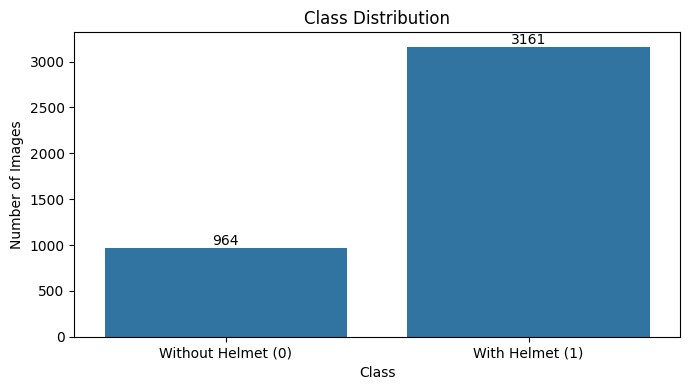

Majority-to-minority ratio: 3.28:1


In [10]:
class_counts = y_all.value_counts().sort_index()
class_percent = (class_counts / len(y_all) * 100).round(2)

class_summary = pd.DataFrame({
    "Class": [label_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": class_percent.values
}, index=class_counts.index)

display(class_summary)

plt.figure(figsize=(7, 4))
ax = sns.countplot(x=y_all, order=[0, 1])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks([0, 1], ["Without Helmet (0)", "With Helmet (1)"])

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")


### Class Distribution — Observations

- The target classes are clearly imbalanced:
  - **Without Helmet:** 964 images (**23.37%**)
  - **With Helmet:** 3,161 images (**76.63%**)
- The **With Helmet** class is approximately **3.28 times larger** than the Without Helmet class.
- Due to this imbalance, overall accuracy alone could be misleading. A model could achieve high accuracy mainly by performing well on the majority class.
- Therefore, the evaluation should include precision, recall, F1-score and confusion matrices in addition to accuracy.
- For SafeGuard Corp, **Recall for the Without Helmet class is especially important**, because an actual worker without a helmet incorrectly classified as wearing one represents a missed safety violation.
- This safety consideration is used later when selecting the final model.

### **EDA Observations**

- The dataset contains **4,125 RGB images** of size **200 × 200 × 3**, with pixel values in the standard 0–255 range.
- The visual samples show meaningful real-world variation in worker appearance, background, pose, viewing angle, and workplace setting. This makes the task more representative than a highly controlled image dataset.
- The target is **imbalanced**: **3,161 images (76.63%)** belong to the *With Helmet* class, whereas **964 images (23.37%)** belong to the *Without Helmet* class. The majority class is therefore about **3.28 times** the minority class.
- Because of this imbalance, **accuracy alone can be misleading**. In addition to overall accuracy, precision, recall and F1-score, the evaluation will specifically monitor **recall for the Without Helmet class**. Missing a worker who is not wearing a helmet is the more safety-critical error because the system would incorrectly treat a non-compliant situation as compliant.
- The train, validation and test partitions should therefore be **stratified** so that the same class proportions are maintained across all three datasets.


# **Data Preprocessing**

### Splitting the dataset



In [11]:
# Use a stratified 70% / 15% / 15% split.
# The test set remains untouched until the final model has been selected.

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    y_all,
    test_size=0.30,
    random_state=812,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=812,
    stratify=y_temp
)

print("Training set  :", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set      :", X_test.shape, y_test.shape)

split_distribution = pd.DataFrame({
    "Train %": y_train.value_counts(normalize=True).sort_index() * 100,
    "Validation %": y_val.value_counts(normalize=True).sort_index() * 100,
    "Test %": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_distribution.index = ["Without Helmet (0)", "With Helmet (1)"]
print("\nClass proportions after stratified splitting:")
display(split_distribution)


Training set  : (2887, 200, 200, 3) (2887,)
Validation set: (619, 200, 200, 3) (619,)
Test set      : (619, 200, 200, 3) (619,)

Class proportions after stratified splitting:


,Train %,Validation %,Test %
Without Helmet (0),23.38,23.42,23.26
With Helmet (1),76.62,76.58,76.74


### Train / Validation / Test Split — Observations

- The dataset was divided into approximately:
  - **70% training**
  - **15% validation**
  - **15% test**
- This resulted in:
  - **2,887 training images**
  - **619 validation images**
  - **619 test images**
- Stratification preserved the original class proportions very closely across the three datasets.
- The percentage of Without Helmet images remains approximately **23%** in the training, validation and test sets, which makes the performance comparison more reliable.
- The validation data is used for model comparison and model selection, while the test set is kept separate until the final evaluation.
- This prevents the test set from influencing model development and gives a cleaner estimate of performance on unseen data.

### Data Normalization

In [12]:
# Normalize image pixels from [0, 255] to [0, 1].
X_train_normalized = X_train.astype("float32") / 255.0
X_val_normalized = X_val.astype("float32") / 255.0
X_test_normalized = X_test.astype("float32") / 255.0

print("Training normalized range  :", X_train_normalized.min(), "to", X_train_normalized.max())
print("Validation normalized range:", X_val_normalized.min(), "to", X_val_normalized.max())
print("Test normalized range      :", X_test_normalized.min(), "to", X_test_normalized.max())


Training normalized range  : 0.0 to 1.0
Validation normalized range: 0.0 to 1.0
Test normalized range      : 0.0 to 1.0


### Normalization — Observations

- The image pixel values were normalized from **0–255 to 0–1**.
- Normalization places all image inputs on a consistent scale and improves numerical stability during neural-network optimization.
- The image dimensions remain unchanged after normalization, so no image information is lost during this preprocessing step.
- The same normalization procedure is consistently applied to the training, validation and test images, ensuring that all models receive comparable inputs.

### **Pre-processing Observations**

- A **stratified 70% / 15% / 15% split** is used so that training, validation and test sets retain approximately the same helmet/no-helmet proportions as the full dataset.
- The test set is kept separate from model development and is only used once, after final model selection.
- Pixel values are normalized from **0–255 to 0–1**, which improves numerical stability during neural-network training.
- No data augmentation is applied to validation or test data. Augmentation is introduced only for Model 4 and only on the training set.


# **Model Building**

## Model Evaluation Criterion

The classes are imbalanced, and the minority class (**Without Helmet = 0**) is the most important class from a workplace-safety perspective. A missed non-compliant worker could result in a safety risk being overlooked.

Accordingly, model performance will be assessed using:
- **Accuracy** for overall correctness,
- **Weighted Precision, Recall and F1-score** to summarize performance while accounting for class frequency,
- **Recall for Without Helmet (class 0)** as a safety-focused metric,
- **Confusion matrices** to inspect the types of classification errors.

The **validation set** will be used to compare and select models. The **test set will only be evaluated after final model selection** to provide an unbiased estimate of generalization.


## Utility Functions

In [14]:
def plot_training_history(history, model_name):
    """Plot accuracy and loss curves separately for clear overfitting/generalization checks."""
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [15]:
def model_performance_classification(model, predictors, target):
    """
    Compute overall and class-specific classification metrics.
    Class 0 = Without Helmet; Class 1 = With Helmet.
    """
    prob = model.predict(predictors, verbose=0).reshape(-1)
    pred = (prob > 0.5).astype(int)
    target_array = np.asarray(target).reshape(-1)

    return pd.DataFrame({
        "Accuracy": [accuracy_score(target_array, pred)],
        "Recall (Weighted)": [recall_score(target_array, pred, average="weighted", zero_division=0)],
        "Precision (Weighted)": [precision_score(target_array, pred, average="weighted", zero_division=0)],
        "F1 Score (Weighted)": [f1_score(target_array, pred, average="weighted", zero_division=0)],
        "Recall - Without Helmet": [recall_score(target_array, pred, pos_label=0, zero_division=0)],
        "Recall - With Helmet": [recall_score(target_array, pred, pos_label=1, zero_division=0)]
    })


In [16]:
def plot_confusion_matrix(model, predictors, target):
    """Plot a clearly labelled confusion matrix for helmet compliance."""
    prob = model.predict(predictors, verbose=0).reshape(-1)
    pred = (prob > 0.5).astype(int)
    target_array = np.asarray(target).reshape(-1)

    cm = confusion_matrix(target_array, pred, labels=[0, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Without Helmet", "With Helmet"],
        yticklabels=["Without Helmet", "With Helmet"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


##Model 1: Convolutional Neural Network (CNN) from Scratch

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       320,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,257 (1.58 MB)

 Trainable params: 413,257 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7880 - loss: 0.4138 - val_accuracy: 0.8352 - val_loss: 0.3224
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8833 - loss: 0.3013 - val_accuracy: 0.8982 - val_loss: 0.2876
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8947 - loss: 0.2832 - val_accuracy: 0.8982 - val_loss: 0.2842
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9086 - loss: 0.2655 - val_accuracy: 0.8821 - val_loss: 0.3204
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9006 - loss: 0.2666 - val_accuracy: 0.8950 - val_loss: 0.2959
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9172 - loss: 0.2428 - val_accuracy: 0.9241 - val_loss: 0.2280
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9221 - loss: 0.2282 - val_accuracy: 0.8546 - val_loss: 0.4602
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9127 - loss: 0.2434 - val_accuracy: 0.9063 - v

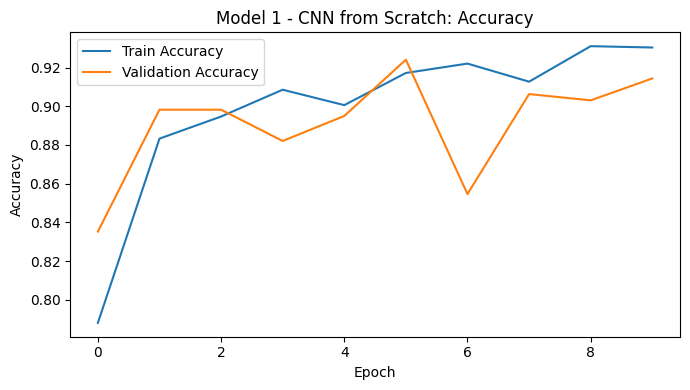

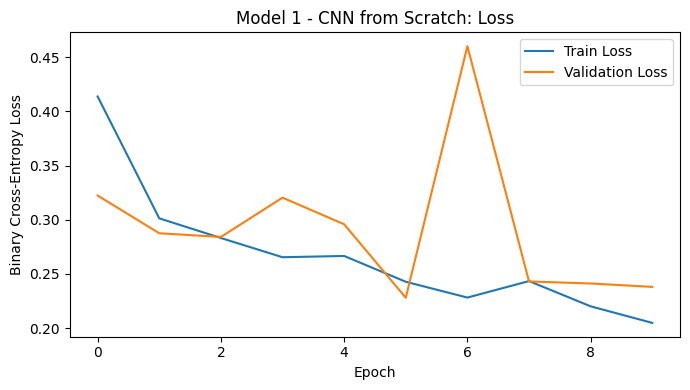

Training performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.943886,0.943886,0.943455,0.943621,0.866667,0.96745


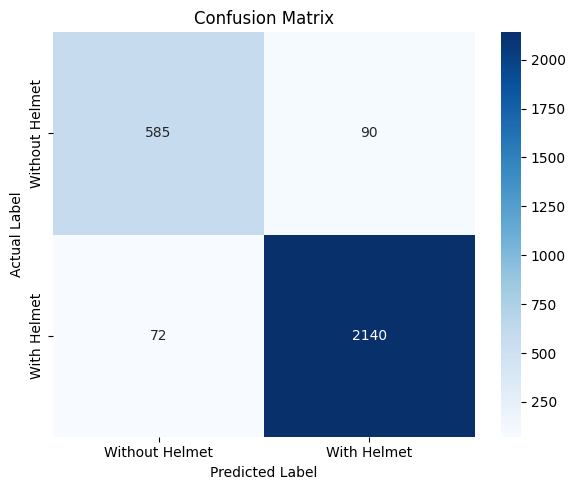

Validation performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.914378,0.914378,0.913482,0.913852,0.8,0.949367


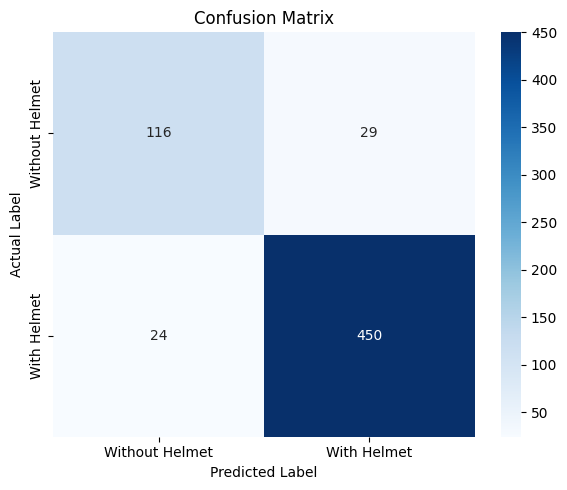

In [17]:
# Model 1: CNN built from scratch
model_1 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(200, 200, 3)),
    MaxPooling2D((4, 4), padding="same"),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),

    Conv2D(128, (3, 3), activation="relu", padding="same"),

    Flatten(),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

history_1 = model_1.fit(
    X_train_normalized,
    y_train,
    validation_data=(X_val_normalized, y_val),
    epochs=10,
    batch_size=32,
    shuffle=True,
    verbose=1
)

# Training history: inspect both accuracy and loss for overfitting/generalization.
plot_training_history(history_1, "Model 1 - CNN from Scratch")

# Performance
model_1_train_perf = model_performance_classification(model_1, X_train_normalized, y_train)
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized, y_val)

print("Training performance")
display(model_1_train_perf)
plot_confusion_matrix(model_1, X_train_normalized, y_train)

print("Validation performance")
display(model_1_valid_perf)
plot_confusion_matrix(model_1, X_val_normalized, y_val)


### Model 1 Architecture — Observations

- Model 1 is a CNN developed completely from scratch and therefore does not use any externally learned image representations.
- The convolutional layers learn increasingly complex visual patterns directly from the HelmNet training images, while pooling progressively reduces the spatial dimensions.
- The dense classification layers convert the extracted features into the final binary helmet-compliance prediction.
- This model provides an appropriate **baseline** against which the VGG-16 transfer-learning models can be compared.
- Because the network must learn all visual representations from the available HelmNet data, it may require more task-specific learning than a pre-trained architecture.

### Visualizing the predictions

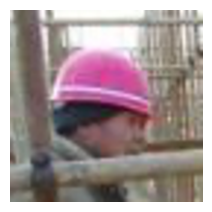

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 1.0000



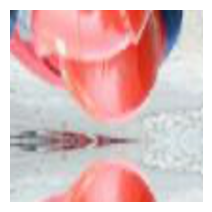

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 0.9905



In [18]:
# Display two validation predictions for Model 1.
sample_indices = [12, 33]

for idx in sample_indices:
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(X_val[idx])
    plt.axis("off")
    plt.show()

    probability = model_1.predict(X_val_normalized[idx:idx+1], verbose=0)[0][0]
    predicted_label = int(probability > 0.5)

    print("Predicted:", f"{label_names[predicted_label]} ({predicted_label})")
    print("Actual   :", f"{label_names[int(y_val.iloc[idx])]} ({int(y_val.iloc[idx])})")
    print(f"P(With Helmet): {probability:.4f}\n")


### Model 1 Training & Validation Performance — Observations

Model 1 achieved:

- **Training Accuracy:** 94.39%
- **Training Weighted F1:** 94.36%
- **Training Recall – Without Helmet:** 86.67%
- **Validation Accuracy:** 91.44%
- **Validation Weighted F1:** 91.39%
- **Validation Recall – Without Helmet:** 80.00%
- **Validation Recall – With Helmet:** 94.94%

#### Interpretation

- The CNN learns the classification task effectively and achieves strong validation accuracy despite being trained entirely from scratch.
- The training-to-validation accuracy gap is approximately **2.95 percentage points**, indicating some overfitting but not an excessive amount.
- Validation performance is substantially stronger for the **With Helmet** class than for the **Without Helmet** class.
- The model correctly identifies about **80% of the no-helmet validation cases**, meaning approximately one in five unsafe cases is still missed.
- This is important because the minority Without Helmet class is the more safety-critical class.
- The training curves also show some validation fluctuation during later epochs, suggesting that generalization does not improve consistently with continued training.
- Overall, Model 1 provides a strong baseline but leaves room for improvement in identifying workers without helmets.

### **Model 1 Observations**

**Architecture**
- The first model is a compact CNN trained completely from scratch. It must learn low-level visual patterns and the final helmet/no-helmet decision only from the HelmNet training images.
- This makes it an important **baseline** for judging the value added by transfer learning.

**Training behavior**
- Compare both the **accuracy curves and loss curves**. A widening train-validation gap, especially if validation loss begins to rise while training loss falls, would indicate overfitting.
- Because this model has no pre-trained visual knowledge, slower convergence than VGG-16 models would be expected.

**Performance**
- Overall accuracy alone is not sufficient because the dataset contains many more helmet images than no-helmet images.
- The validation confusion matrix and **Recall - Without Helmet** should therefore receive special attention.
- The most safety-critical error is an actual **Without Helmet** worker being predicted as **With Helmet**, since that can allow non-compliance to go undetected.

**Key insight**
- Model 1 establishes how well a task-specific CNN can perform without transfer learning. The later models should be judged on whether they improve validation generalization and minority-class detection rather than merely fitting the training data better.


## Model 2: Transfer Learning with VGG-16 (Base)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.8227 - loss: 0.3841 - val_accuracy: 0.8934 - val_loss: 0.2950
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.8999 - loss: 0.2447 - val_accuracy: 0.8998 - val_loss: 0.2541
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.9214 - loss: 0.1992 - val_accuracy: 0.9128 - val_loss: 0.2278
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.9338 - loss: 0.1728 - val_accuracy: 0.9031 - val_loss: 0.2297
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - accuracy: 0.9297 - loss: 0.1741 - val_accuracy: 0.8998 - val_loss: 0.2441
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.9522 - loss: 0.1330 - val_accuracy: 0.9273 - val_loss: 0.2026
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.9574 - loss: 0.1255 - val_accuracy: 0.9160 - val_loss: 0.1992
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.9654 - loss: 0.1116 - val_accu

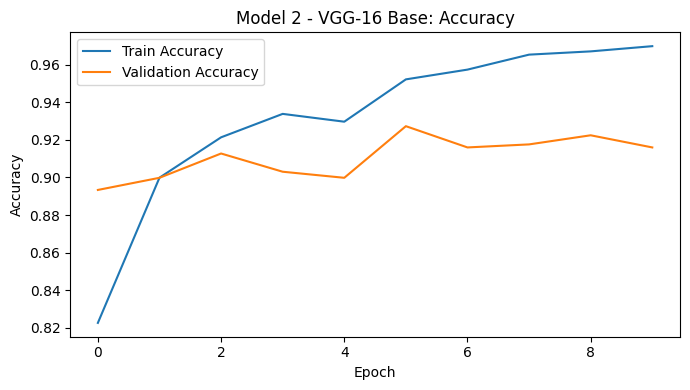

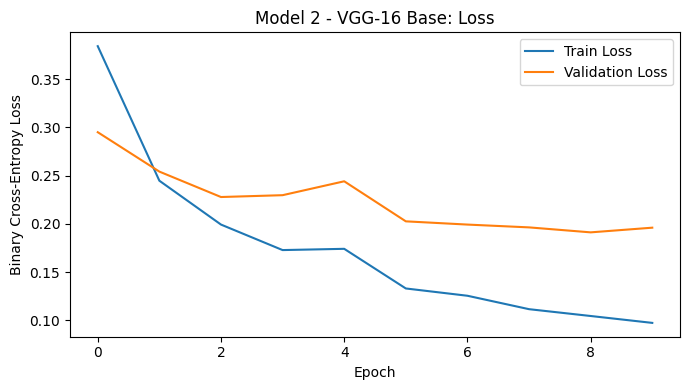

Training performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.978871,0.978871,0.978798,0.978821,0.948148,0.988246


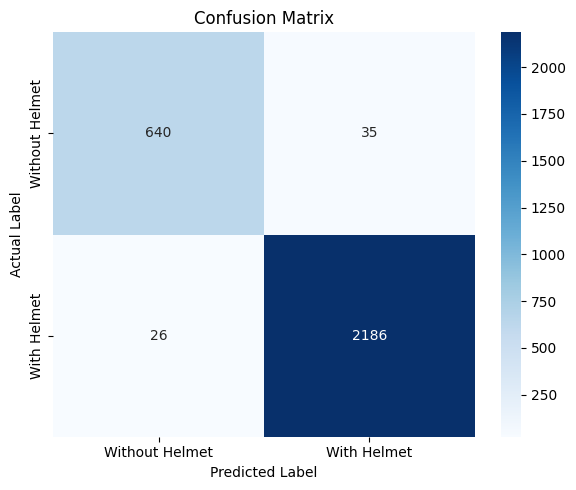

Validation performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.915994,0.915994,0.914515,0.914932,0.786207,0.955696


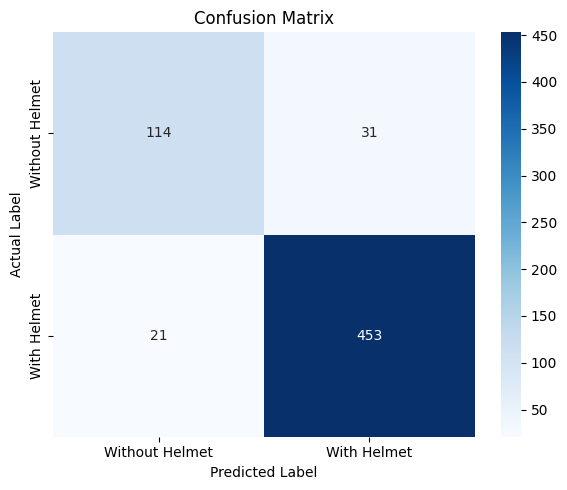

In [19]:
# Model 2: VGG-16 convolutional base + sigmoid output layer
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(200, 200, 3)
)

# Freeze all pre-trained convolutional layers.
for layer in vgg_base.layers:
    layer.trainable = False

model_2 = Sequential([
    vgg_base,
    Flatten(),
    Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

epochs = 10
batch_size = 32
plain_datagen = ImageDataGenerator()

history_2 = model_2.fit(
    plain_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=batch_size,
        seed=812,
        shuffle=True
    ),
    epochs=epochs,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

plot_training_history(history_2, "Model 2 - VGG-16 Base")

model_2_train_perf = model_performance_classification(model_2, X_train_normalized, y_train)
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized, y_val)

print("Training performance")
display(model_2_train_perf)
plot_confusion_matrix(model_2, X_train_normalized, y_train)

print("Validation performance")
display(model_2_valid_perf)
plot_confusion_matrix(model_2, X_val_normalized, y_val)


### Model 2 Architecture — Observations

- Model 2 uses **VGG-16 pre-trained on ImageNet** as a frozen convolutional feature extractor.
- The pre-trained layers provide visual representations learned from a much larger and more diverse image dataset.
- Only the new classification head is trained for the HelmNet binary classification problem.
- Freezing the VGG-16 base substantially reduces the number of trainable parameters and helps preserve the useful pre-trained visual features.
- This model tests whether transfer learning improves the classification performance compared with the CNN trained from scratch.

### Visualizing the predictions

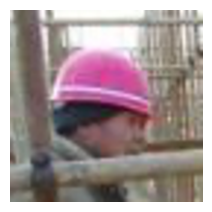

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 1.0000



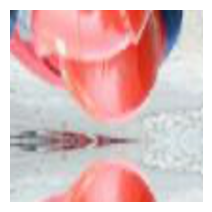

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 0.9986



In [20]:
# Display two validation predictions for Model 2.
sample_indices = [12, 33]

for idx in sample_indices:
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(X_val[idx])
    plt.axis("off")
    plt.show()

    probability = model_2.predict(X_val_normalized[idx:idx+1], verbose=0)[0][0]
    predicted_label = int(probability > 0.5)

    print("Predicted:", f"{label_names[predicted_label]} ({predicted_label})")
    print("Actual   :", f"{label_names[int(y_val.iloc[idx])]} ({int(y_val.iloc[idx])})")
    print(f"P(With Helmet): {probability:.4f}\n")


### Model 2 Training & Validation Performance — Observations

Model 2 achieved:

- **Training Accuracy:** 97.89%
- **Training Weighted F1:** 97.88%
- **Training Recall – Without Helmet:** 94.81%
- **Validation Accuracy:** 91.60%
- **Validation Weighted F1:** 91.49%
- **Validation Recall – Without Helmet:** 78.62%
- **Validation Recall – With Helmet:** 95.57%

#### Interpretation

- Model 2 produces the **highest training accuracy** among the four models, showing that the VGG-16 features separate the training images very effectively.
- Validation accuracy improves only slightly over Model 1, from 91.44% to **91.60%**.
- However, validation recall for **Without Helmet decreases from 80.00% to 78.62%**.
- At the same time, recall for With Helmet improves to **95.57%**, indicating that the model is especially strong on the majority class.
- The training-validation accuracy gap is approximately **6.29 percentage points**, the largest of the four models.
- The no-helmet recall gap between training and validation is also large, suggesting that some of the strong training performance does not generalize to the minority class.
- Therefore, Model 2 should not be selected based only on its high training performance.

### **Model 2 Observations**

**Architecture**
- Model 2 uses the convolutional part of **VGG-16 pre-trained on ImageNet** as a frozen feature extractor, with a new sigmoid classifier for HelmNet.
- Freezing the VGG-16 layers reduces the number of trainable parameters and allows the model to reuse broadly useful visual representations learned from a much larger image dataset.

**Training behavior**
- Transfer learning should normally converge faster than the scratch CNN because the network does not need to relearn basic visual representations from the beginning.
- The accuracy and loss curves should be checked for stability and for the size of the train-validation gap.

**Performance**
- The important comparison with Model 1 is whether VGG-16 improves validation **Accuracy, Weighted F1 and Recall - Without Helmet**.
- The confusion matrix should be inspected for actual no-helmet workers predicted as helmeted.

**Key insight**
- If Model 2 generalizes better than Model 1, it provides evidence that pre-trained visual features are useful for this task even though VGG-16 was not originally trained specifically for safety-helmet classification.
- Strong validation results are encouraging, but they do not by themselves prove robustness to every real workplace camera condition.


## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,082,433 (65.16 MB)

 Trainable params: 2,367,745 (9.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.7426 - loss: 0.5440 - val_accuracy: 0.8368 - val_loss: 0.3464
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - accuracy: 0.8088 - loss: 0.3893 - val_accuracy: 0.8772 - val_loss: 0.3208
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.8438 - loss: 0.3345 - val_accuracy: 0.8853 - val_loss: 0.2869
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8511 - loss: 0.2968 - val_accuracy: 0.9128 - val_loss: 0.2538
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.8628 - loss: 0.2714 - val_accuracy: 0.8255 - val_loss: 0.3581
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8798 - loss: 0.2609 - val_accuracy: 0.9192 - val_loss: 0.2279
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.8881 - loss: 0.2445 - val_accuracy: 0.8998 - val_loss: 0.2577
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8937 - loss: 0.2204 - val_accu

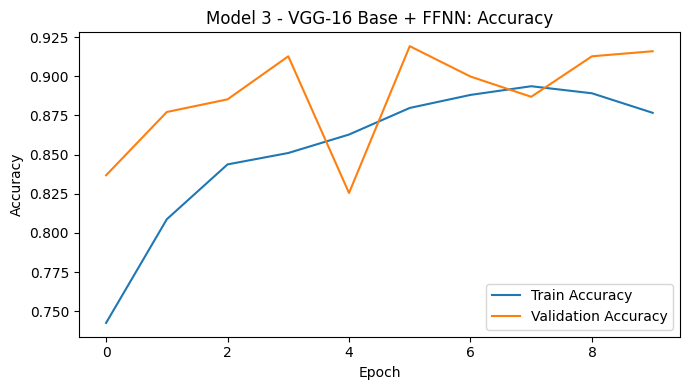

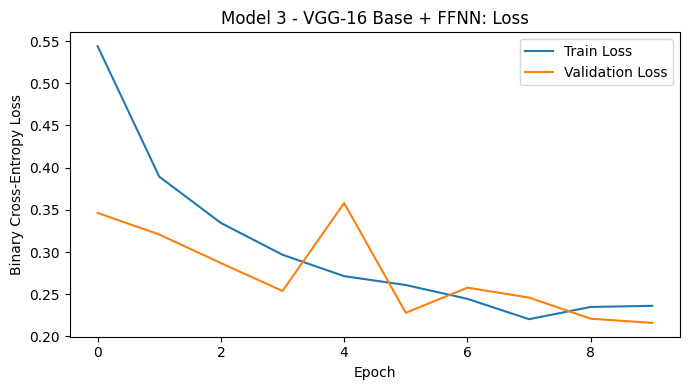

Training performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.959474,0.959474,0.959251,0.959336,0.903704,0.976492


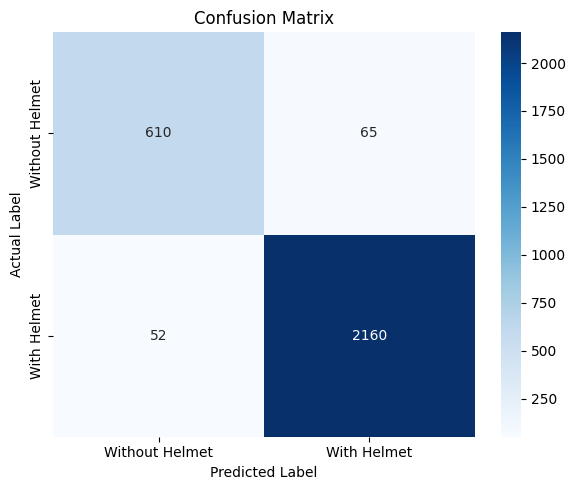

Validation performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.915994,0.915994,0.916878,0.916387,0.834483,0.940928


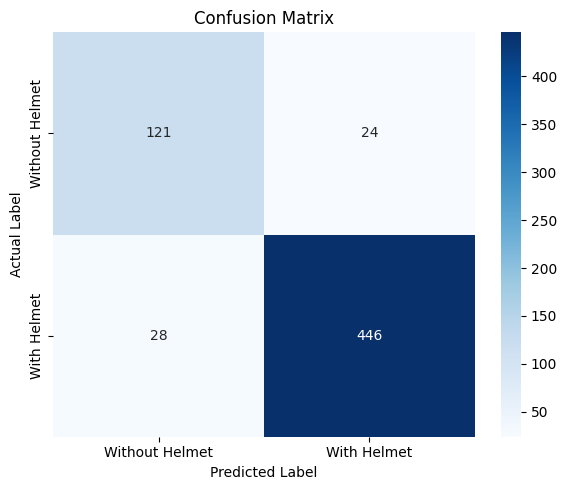

In [21]:
# Model 3: VGG-16 base + feed-forward neural network (FFNN)
model_3 = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

history_3 = model_3.fit(
    plain_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=32,
        seed=812,
        shuffle=True
    ),
    epochs=10,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

plot_training_history(history_3, "Model 3 - VGG-16 Base + FFNN")

model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized, y_val)

print("Training performance")
display(model_3_train_perf)
plot_confusion_matrix(model_3, X_train_normalized, y_train)

print("Validation performance")
display(model_3_valid_perf)
plot_confusion_matrix(model_3, X_val_normalized, y_val)


### Model 3 Architecture — Observations

- Model 3 retains the frozen VGG-16 convolutional base and adds a custom **feed-forward neural network with 128 and 64-unit dense layers**.
- The additional dense layers allow the model to learn a more task-specific decision boundary from the VGG-16 features.
- **Dropout of 0.5** is included as a regularization technique to reduce the risk of overfitting from the increased classifier capacity.
- This architecture therefore combines general pre-trained visual representations with more flexible task-specific classification layers.

#### Visualizing the predictions

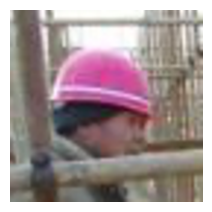

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 1.0000



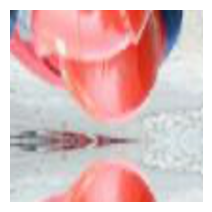

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 0.9978



In [22]:
# Display two validation predictions for Model 3.
sample_indices = [12, 33]

for idx in sample_indices:
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(X_val[idx])
    plt.axis("off")
    plt.show()

    probability = model_3.predict(X_val_normalized[idx:idx+1], verbose=0)[0][0]
    predicted_label = int(probability > 0.5)

    print("Predicted:", f"{label_names[predicted_label]} ({predicted_label})")
    print("Actual   :", f"{label_names[int(y_val.iloc[idx])]} ({int(y_val.iloc[idx])})")
    print(f"P(With Helmet): {probability:.4f}\n")


### Model 3 Training & Validation Performance — Observations

Model 3 achieved:

- **Training Accuracy:** 95.95%
- **Training Weighted F1:** 95.93%
- **Training Recall – Without Helmet:** 90.37%
- **Validation Accuracy:** 91.60%
- **Validation Weighted F1:** **91.64%**
- **Validation Recall – Without Helmet:** **83.45%**
- **Validation Recall – With Helmet:** 94.09%

#### Interpretation

- Model 3 achieves the same overall validation accuracy as Model 2 at **91.60%**, but its class-level performance is better balanced.
- Most importantly, recall for the safety-critical **Without Helmet** class rises to **83.45%**, the highest of all four models at the default 0.50 threshold.
- Weighted F1 also reaches **91.64%**, which is the strongest validation F1 result in the comparison.
- Compared with Model 2, adding the FFNN improves minority-class detection even though With Helmet recall reduces slightly.
- The training-validation accuracy gap is approximately **4.35 percentage points**, lower than Model 2's gap.
- The results suggest that the custom classifier learns a more useful decision boundary for the HelmNet safety objective rather than simply maximizing majority-class performance.
- Based on the safety-first selection criterion, Model 3 is the strongest candidate for final evaluation.

### **Model 3 Observations**

**Architecture**
- Model 3 retains the frozen VGG-16 feature extractor and adds a custom **FFNN classifier (128 → 64 → 1)**.
- The dense layers increase task-specific classification capacity, while **Dropout(0.5)** is included to reduce overfitting.

**Training behavior**
- Compare Model 3 with Model 2 using both training and validation curves.
- If training performance improves strongly but validation performance changes little or validation loss worsens, the additional FFNN capacity may be fitting the training set without improving generalization.

**Performance**
- The model should be assessed using validation Accuracy, Weighted F1 and especially **Recall - Without Helmet**.
- A genuine improvement over Model 2 should appear on the validation set, not only on the training set.

**Key insight**
- The VGG-16 base provides general visual feature extraction while the FFNN gives the classifier more flexibility to adapt those features to the helmet-compliance decision.
- The value of this added flexibility depends on the observed validation results; more layers are not automatically better.


## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

**For HelmNet:** augmentation is applied to the training set only. The chosen transformations represent plausible geometric/positional variation; vertical flipping is avoided because it would create unrealistic worker orientation.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,082,433 (65.16 MB)

 Trainable params: 2,367,745 (9.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 457ms/step - accuracy: 0.7423 - loss: 0.5741 - val_accuracy: 0.8401 - val_loss: 0.3756
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 440ms/step - accuracy: 0.7936 - loss: 0.4094 - val_accuracy: 0.8207 - val_loss: 0.3382
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 39s 430ms/step - accuracy: 0.8202 - loss: 0.3777 - val_accuracy: 0.8481 - val_loss: 0.3113
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 39s 428ms/step - accuracy: 0.8254 - loss: 0.3667 - val_accuracy: 0.8675 - val_loss: 0.3025
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 445ms/step - accuracy: 0.8258 - loss: 0.3443 - val_accuracy: 0.8401 - val_loss: 0.3077
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 440ms/step - accuracy: 0.8386 - loss: 0.3221 - val_accuracy: 0.8901 - val_loss: 0.2622
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 39s 424ms/step - accuracy: 0.8220 - loss: 0.3303 - val_accuracy: 0.8821 - val_loss: 0.2637
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 38s 422ms/step - accuracy: 0.8421 - loss: 0.3329 - val_accu

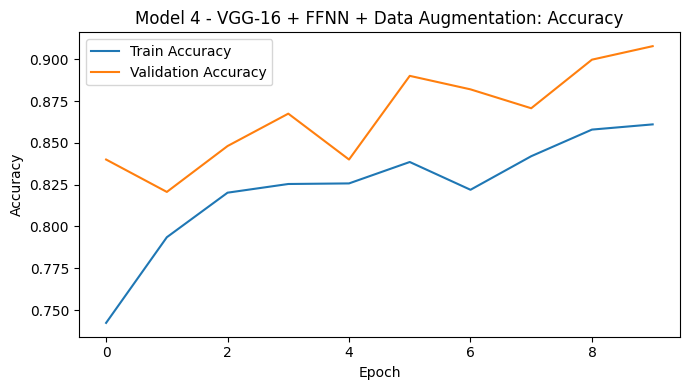

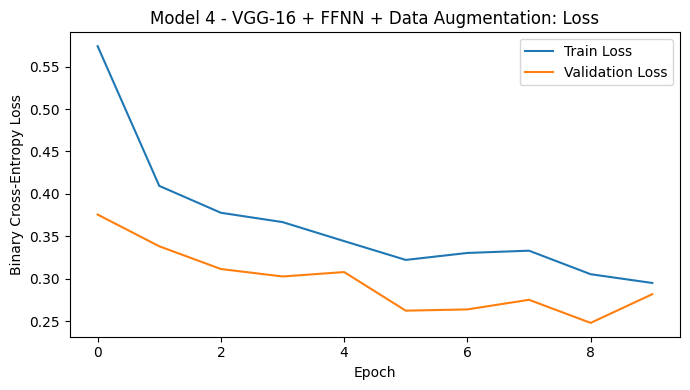

Training performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.924143,0.924143,0.922719,0.922404,0.777778,0.968807


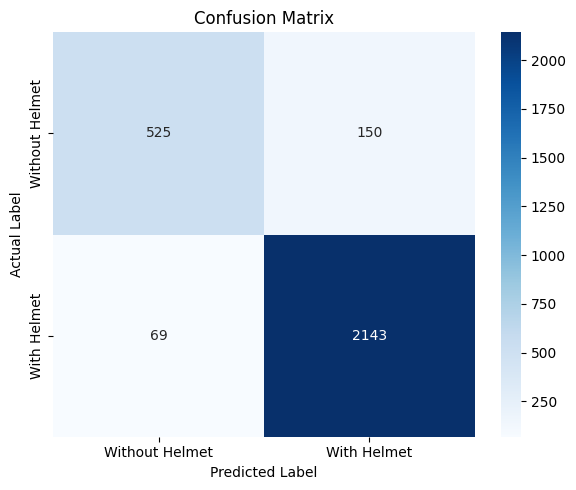

Validation performance


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.907916,0.907916,0.905664,0.905319,0.731034,0.962025


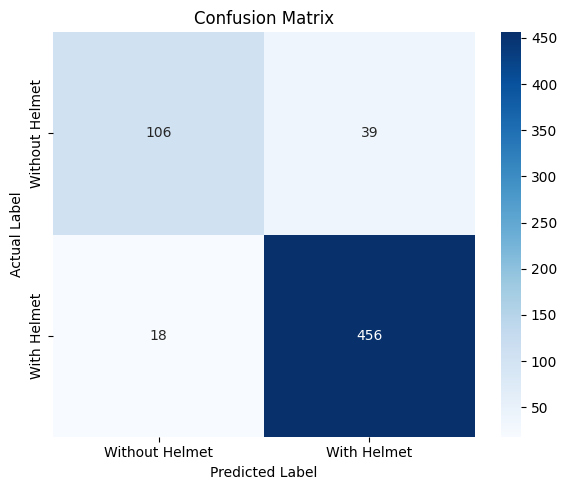

In [23]:
# Model 4: VGG-16 base + FFNN + training-only data augmentation
model_4 = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_4.summary()

# Use realistic augmentations for worker images.
# Vertical flipping is intentionally avoided because upside-down workers are not a realistic camera condition.
augment_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

history_4 = model_4.fit(
    augment_datagen.flow(
        X_train_normalized,
        y_train,
        batch_size=32,
        seed=812,
        shuffle=True
    ),
    epochs=10,
    validation_data=(X_val_normalized, y_val),
    verbose=1
)

plot_training_history(history_4, "Model 4 - VGG-16 + FFNN + Data Augmentation")

model_4_train_perf = model_performance_classification(model_4, X_train_normalized, y_train)
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized, y_val)

print("Training performance")
display(model_4_train_perf)
plot_confusion_matrix(model_4, X_train_normalized, y_train)

print("Validation performance")
display(model_4_valid_perf)
plot_confusion_matrix(model_4, X_val_normalized, y_val)


### Data Augmentation — Observations

- Data augmentation is applied **only to the training data**, while validation and test images remain unchanged.
- The transformations include rotation, translation, shear, zoom and horizontal flipping.
- These transformations expose the model to different positional, scale and viewpoint variations of the existing training images.
- This acts as a form of regularization because the classifier sees modified versions of the training data rather than repeatedly seeing exactly the same images.
- Vertical flipping is appropriately excluded because upside-down workers would not normally represent a realistic workplace-monitoring scenario.
- The current augmentation mainly addresses geometric variation; it does not directly simulate all possible real-world challenges such as severe low light, glare, motion blur or heavy occlusion.

#### Visualizing the predictions

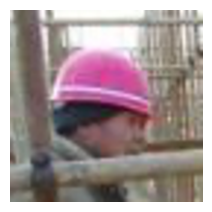

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 1.0000



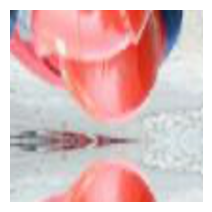

Predicted: With Helmet (1)
Actual   : With Helmet (1)
P(With Helmet): 0.9900



In [24]:
# Display two validation predictions for Model 4.
sample_indices = [12, 33]

for idx in sample_indices:
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(X_val[idx])
    plt.axis("off")
    plt.show()

    probability = model_4.predict(X_val_normalized[idx:idx+1], verbose=0)[0][0]
    predicted_label = int(probability > 0.5)

    print("Predicted:", f"{label_names[predicted_label]} ({predicted_label})")
    print("Actual   :", f"{label_names[int(y_val.iloc[idx])]} ({int(y_val.iloc[idx])})")
    print(f"P(With Helmet): {probability:.4f}\n")


### **Model 4 Observations**

**Architecture**
- Model 4 combines the frozen VGG-16 feature extractor and FFNN classifier with **data augmentation applied only to training images**.
- Validation and test images remain unchanged, so evaluation is performed on the original data distribution without augmentation leakage.

**Training behavior**
- Rotation, width/height shifts, shear, zoom and horizontal flipping generate plausible variation in worker position, scale and viewpoint.
- Training accuracy can be lower or noisier than Model 3 because the model sees modified images during training. This is not necessarily negative if validation performance remains strong.
- Vertical flipping is intentionally excluded because upside-down workers are not representative of normal workplace camera imagery.

**Performance**
- The central question is whether augmentation improves or stabilizes validation performance, particularly **Recall - Without Helmet**, while maintaining strong overall F1 and accuracy.
- A smaller train-validation gap would provide evidence that augmentation is acting as useful regularization.

**Key insight**
- Data augmentation does not prove robustness to every real-world condition, but it reduces dependence on the exact position/orientation of training images and therefore provides a stronger robustness-oriented design.
- Lighting variation, heavy motion blur and severe occlusion are **not directly created by the current augmentation settings** and should still be validated separately.


### **Qualitative Validation Prediction Review**

In addition to numerical metrics, the following cell displays a small random sample of validation images together with the true label, predicted label and predicted probability.

This does **not** replace full-set evaluation. Its purpose is to visually inspect whether correct and incorrect predictions appear sensible and to identify examples that may warrant further investigation.


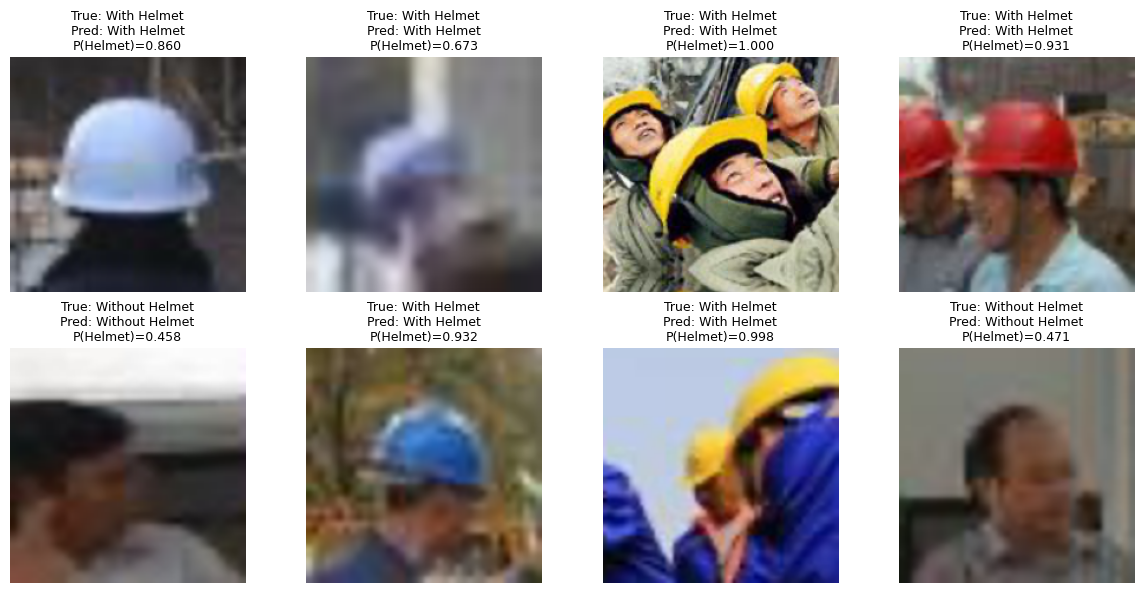

In [25]:
# Qualitative prediction review on a reproducible random validation sample.
rng_review = np.random.default_rng(812)
review_indices = rng_review.choice(len(X_val), size=min(8, len(X_val)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, review_indices):
    p_helmet = float(model_4.predict(
        X_val_normalized[idx:idx+1], verbose=0
    ).reshape(-1)[0])
    pred_label = int(p_helmet >= 0.5)
    true_label = int(np.asarray(y_val).reshape(-1)[idx])

    ax.imshow(X_val[idx])
    ax.axis("off")
    ax.set_title(
        f"True: {label_names[true_label]}\n"
        f"Pred: {label_names[pred_label]}\n"
        f"P(Helmet)={p_helmet:.3f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()


### Model 4 Training & Validation Performance — Observations

Model 4 achieved:

- **Training Accuracy:** 92.41%
- **Training Weighted F1:** 92.24%
- **Training Recall – Without Helmet:** 77.78%
- **Validation Accuracy:** 90.79%
- **Validation Weighted F1:** 90.53%
- **Validation Recall – Without Helmet:** 73.10%
- **Validation Recall – With Helmet:** approximately 96.2%

#### Interpretation

- Model 4 has lower training performance than Model 3, which is expected because augmentation makes the training task more difficult by continuously modifying the input images.
- Its validation accuracy of **90.79%** is slightly lower than the other three models.
- The most important weakness is the **73.10% recall for Without Helmet**, the lowest no-helmet validation recall among the four models.
- Therefore, augmentation did not improve the safety-critical classification objective in this particular run.
- However, Model 4 has the **smallest training-validation accuracy gap, approximately 1.62 percentage points**, indicating the strongest regularization and the closest alignment between training and validation performance.
- This shows that augmentation improved training-validation consistency, but it did **not** produce the best predictive performance.
- Therefore, Model 4 should not be selected simply because it includes data augmentation.

# **Model Performance Comparison and Final Model Selection**

In [26]:
# Compare training and validation performance across all four models.
model_names = [
    "CNN from Scratch",
    "VGG-16 Base",
    "VGG-16 Base + FFNN",
    "VGG-16 Base + FFNN + Augmentation"
]

train_perf_list = [
    model_1_train_perf,
    model_2_train_perf,
    model_3_train_perf,
    model_4_train_perf
]

valid_perf_list = [
    model_1_valid_perf,
    model_2_valid_perf,
    model_3_valid_perf,
    model_4_valid_perf
]

models_train_comp_df = pd.concat(train_perf_list, ignore_index=True)
models_train_comp_df.index = model_names

models_valid_comp_df = pd.concat(valid_perf_list, ignore_index=True)
models_valid_comp_df.index = model_names

print("Training Performance Comparison")
display(models_train_comp_df.round(4))

print("\nValidation Performance Comparison")
display(models_valid_comp_df.round(4))

print("\nTrain - Validation Performance Gap")
display((models_train_comp_df - models_valid_comp_df).round(4))

# Safety-first model selection:
# 1) Highest validation recall for Without Helmet
# 2) Highest validation weighted F1
# 3) Highest validation accuracy
ranking = models_valid_comp_df.sort_values(
    by=["Recall - Without Helmet", "F1 Score (Weighted)", "Accuracy"],
    ascending=False
)

top_recall = ranking.iloc[0]["Recall - Without Helmet"]
top_f1 = ranking.iloc[0]["F1 Score (Weighted)"]
top_acc = ranking.iloc[0]["Accuracy"]

# If several models are effectively tied on the three validation criteria,
# prefer the augmented VGG-16 model because it has the strongest robustness-oriented design.
tolerance = 1e-6
tied_models = ranking[
    (np.abs(ranking["Recall - Without Helmet"] - top_recall) <= tolerance) &
    (np.abs(ranking["F1 Score (Weighted)"] - top_f1) <= tolerance) &
    (np.abs(ranking["Accuracy"] - top_acc) <= tolerance)
].index.tolist()

robustness_preference = [
    "VGG-16 Base + FFNN + Augmentation",
    "VGG-16 Base + FFNN",
    "VGG-16 Base",
    "CNN from Scratch"
]

best_model_name = next(
    (name for name in robustness_preference if name in tied_models),
    ranking.index[0]
)

model_lookup = {
    "CNN from Scratch": model_1,
    "VGG-16 Base": model_2,
    "VGG-16 Base + FFNN": model_3,
    "VGG-16 Base + FFNN + Augmentation": model_4
}

best_model = model_lookup[best_model_name]

print("\nSelected Final Model:", best_model_name)
print(
    "Selection basis: validation Recall for Without Helmet first, "
    "then weighted F1 and Accuracy; augmentation/robustness is used only as a tie-breaker."
)


Training Performance Comparison


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
CNN from Scratch,0.9439,0.9439,0.9435,0.9436,0.8667,0.9675
VGG-16 Base,0.9789,0.9789,0.9788,0.9788,0.9481,0.9882
VGG-16 Base + FFNN,0.9595,0.9595,0.9593,0.9593,0.9037,0.9765
VGG-16 Base + FFNN + Augmentation,0.9241,0.9241,0.9227,0.9224,0.7778,0.9688



Validation Performance Comparison


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
CNN from Scratch,0.9144,0.9144,0.9135,0.9139,0.8000,0.9494
VGG-16 Base,0.9160,0.9160,0.9145,0.9149,0.7862,0.9557
VGG-16 Base + FFNN,0.9160,0.9160,0.9169,0.9164,0.8345,0.9409
VGG-16 Base + FFNN + Augmentation,0.9079,0.9079,0.9057,0.9053,0.7310,0.9620



Train - Validation Performance Gap


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
CNN from Scratch,0.0295,0.0295,0.0300,0.0298,0.0667,0.0181
VGG-16 Base,0.0629,0.0629,0.0643,0.0639,0.1619,0.0325
VGG-16 Base + FFNN,0.0435,0.0435,0.0424,0.0429,0.0692,0.0356
VGG-16 Base + FFNN + Augmentation,0.0162,0.0162,0.0171,0.0171,0.0467,0.0068



Selected Final Model: VGG-16 Base + FFNN
Selection basis: validation Recall for Without Helmet first, then weighted F1 and Accuracy; augmentation/robustness is used only as a tie-breaker.


### Model Performance Comparison — Observations

The validation results show:

| Model | Accuracy | Weighted F1 | Recall – Without Helmet |
|---|---:|---:|---:|
| CNN from Scratch | 91.44% | 91.39% | 80.00% |
| VGG-16 Base | 91.60% | 91.49% | 78.62% |
| **VGG-16 Base + FFNN** | **91.60%** | **91.64%** | **83.45%** |
| VGG-16 Base + FFNN + Augmentation | 90.79% | 90.53% | 73.10% |

#### Interpretation

- All four models achieve strong validation accuracy of approximately 91%, so overall accuracy alone does not clearly differentiate them.
- Model 2 and Model 3 share the highest validation accuracy at **91.60%**.
- Model 3 achieves the **highest Weighted F1-score of 91.64%** and, more importantly, the **highest Without Helmet recall of 83.45%**.
- Model 4 has the smallest train-validation gap, demonstrating effective regularization, but its lower F1-score and much lower no-helmet recall make it less suitable for the safety objective.
- Model 2 shows the largest train-validation gap, suggesting more overfitting despite excellent training performance.
- The comparison demonstrates why class-specific metrics are essential in this imbalanced dataset: the model with the highest training score is not necessarily the model that best identifies unsafe workers.

### **Final Model Selection Rationale**

The four models are compared using the **validation set only**. The test set is deliberately excluded from model selection so that it remains an untouched final check.

The ranking follows a safety-first order:

1. **Recall - Without Helmet** — prioritized because missed non-compliance is the most consequential error.
2. **Weighted F1-score** — checks balanced predictive quality while accounting for the class distribution.
3. **Accuracy** — retained as an overall performance measure.
4. If models are effectively tied, preference is given to the augmented VGG-16 model because its training process intentionally exposes the classifier to plausible positional and viewpoint variation.

This approach is more appropriate than selecting a model only because it has the highest training accuracy.

### Technical interpretation of the model progression

- **CNN from Scratch:** establishes the baseline when all visual representations must be learned from HelmNet.
- **VGG-16 Base:** tests whether transfer learning provides better generalization with fewer trainable parameters.
- **VGG-16 + FFNN:** tests whether additional task-specific classifier capacity improves validation performance.
- **VGG-16 + FFNN + Augmentation:** tests whether robustness-oriented training improves or stabilizes generalization.

The code above prints the model selected from the **actual validation metrics**. Only that model is evaluated on the test set below.


### Final Model Selection — Observations

**Model 3 – VGG-16 Base + FFNN** is selected as the final model.

The main reasons are:

- It achieves the **highest validation Recall – Without Helmet of 83.45%**.
- It achieves the **highest Weighted F1-score of 91.64%**.
- It ties for the highest overall validation accuracy at **91.60%**.
- Its performance is more balanced between the two classes than the VGG-16 base model.
- It provides a better safety trade-off than Model 4, which has stronger regularization but misses more no-helmet cases.
- The selection is based entirely on validation data, keeping the test set independent for the final evaluation.

This selection is aligned with SafeGuard Corp's business objective because identifying a worker without a helmet is more important than maximizing overall accuracy alone.

## **Validation Threshold Sensitivity Analysis**

The neural network outputs a probability for the **With Helmet** class. A threshold of 0.50 is the standard starting point, but in a safety application the operating threshold may later be adjusted.

Because **class 0 = Without Helmet**, increasing the threshold required to declare *With Helmet* makes the system more conservative: more uncertain cases are treated as possible no-helmet cases. This can improve no-helmet recall, but it may also create more false alerts.

The table below explores several thresholds **using validation data only**. It is included to support deployment planning; the primary project comparison remains based on the standard 0.50 threshold.


In [27]:
# Threshold sensitivity is evaluated on validation data only.
# This avoids using the test set to tune an operational decision threshold.

val_prob_best = best_model.predict(X_val_normalized, verbose=0).reshape(-1)
y_val_array = np.asarray(y_val).reshape(-1)

threshold_rows = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_t = (val_prob_best >= threshold).astype(int)

    threshold_rows.append({
        "Threshold for With Helmet": threshold,
        "Accuracy": accuracy_score(y_val_array, pred_t),
        "Weighted F1": f1_score(y_val_array, pred_t, average="weighted", zero_division=0),
        "Recall - Without Helmet": recall_score(
            y_val_array, pred_t, pos_label=0, zero_division=0
        ),
        "Recall - With Helmet": recall_score(
            y_val_array, pred_t, pos_label=1, zero_division=0
        )
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)
display(threshold_analysis_df.round(4))

print(
    "Interpretation: a higher threshold for declaring 'With Helmet' can make the "
    "system more conservative and may increase detection of no-helmet cases, "
    "but it can also increase false alerts. Any production threshold should be "
    "chosen using business risk and site-validation data."
)


,Threshold for With Helmet,Accuracy,Weighted F1,Recall - Without Helmet,Recall - With Helmet
0,0.3,0.9176,0.9137,0.7103,0.9810
1,0.4,0.9208,0.9193,0.7793,0.9641
2,0.5,0.9160,0.9164,0.8345,0.9409
3,0.6,0.8918,0.8948,0.8621,0.9008
4,0.7,0.8659,0.8726,0.9103,0.8523


Interpretation: a higher threshold for declaring 'With Helmet' can make the system more conservative and may increase detection of no-helmet cases, but it can also increase false alerts. Any production threshold should be chosen using business risk and site-validation data.


### Validation Threshold Sensitivity — Observations

- At threshold **0.30**, Without Helmet recall is **71.03%**, while With Helmet recall is very high at **98.10%**.
- At threshold **0.40**, overall accuracy reaches its highest value of **92.08%**, with a Weighted F1 of **91.93%**, but Without Helmet recall remains at **77.93%**.
- At the standard **0.50 threshold**, Without Helmet recall improves to **83.45%**, while overall accuracy remains strong at **91.60%**.
- Increasing the threshold to **0.60** further improves Without Helmet recall to **86.21%**, although accuracy falls to **89.18%**.
- At threshold **0.70**, Without Helmet recall reaches **91.03%**, but overall accuracy declines to **86.59%** and With Helmet recall falls to **85.23%**.

#### Interpretation

- The threshold analysis demonstrates a clear trade-off between **detecting more unsafe workers** and generating more false alerts.
- A lower threshold favours the With Helmet class, while a higher threshold makes the model more conservative before declaring a worker compliant.
- The default 0.50 threshold provides a reasonable overall balance for the project comparison.
- However, in a real workplace-safety deployment, SafeGuard Corp may consider a threshold closer to **0.60** if reducing missed no-helmet cases is more important than avoiding false alarms.
- The operating threshold should ultimately be selected using real-site validation data and the business cost of the two types of error.

## Test Performance

Final model: VGG-16 Base + FFNN

Test performance metrics


,Accuracy,Recall (Weighted),Precision (Weighted),F1 Score (Weighted),Recall - Without Helmet,Recall - With Helmet
0,0.9063,0.9063,0.9045,0.9051,0.7639,0.9495



Test confusion matrix


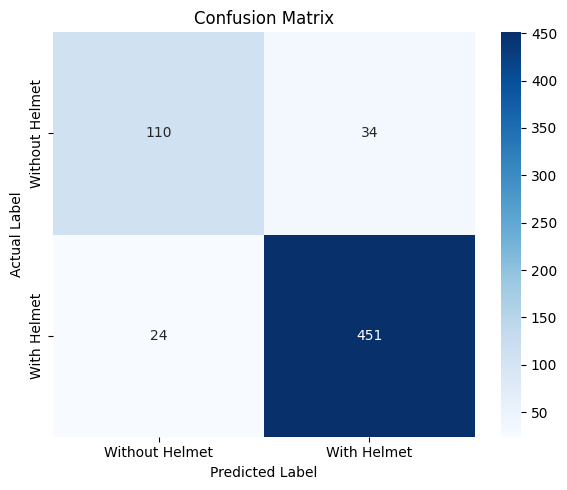


Detailed test classification report
                precision    recall  f1-score   support

Without Helmet     0.8209    0.7639    0.7914       144
   With Helmet     0.9299    0.9495    0.9396       475

      accuracy                         0.9063       619
     macro avg     0.8754    0.8567    0.8655       619
  weighted avg     0.9045    0.9063    0.9051       619



In [28]:
# Final, one-time evaluation on the untouched test set.
model_test_perf = model_performance_classification(
    best_model,
    X_test_normalized,
    y_test
)

print("Final model:", best_model_name)
print("\nTest performance metrics")
display(model_test_perf.round(4))

print("\nTest confusion matrix")
plot_confusion_matrix(best_model, X_test_normalized, y_test)

# Detailed class-wise report for deployment-oriented interpretation.
test_prob = best_model.predict(X_test_normalized, verbose=0).reshape(-1)
test_pred = (test_prob > 0.5).astype(int)

print("\nDetailed test classification report")
print(
    classification_report(
        np.asarray(y_test),
        test_pred,
        labels=[0, 1],
        target_names=["Without Helmet", "With Helmet"],
        digits=4,
        zero_division=0
    )
)


### Final Model Test Performance — Observations

The selected Model 3 achieved the following results on the **619-image untouched test set**:

- **Accuracy:** 90.63%
- **Weighted Precision:** 90.45%
- **Weighted Recall:** 90.63%
- **Weighted F1-score:** 90.51%

Class-specific performance:

#### Without Helmet
- Precision: **82.09%**
- Recall: **76.39%**
- F1-score: **79.14%**
- Support: 144 images

#### With Helmet
- Precision: **92.99%**
- Recall: **94.95%**
- F1-score: **93.96%**
- Support: 475 images

#### Interpretation

- The selected model maintains strong overall performance on unseen test data.
- Performance is substantially stronger for the majority **With Helmet** class than for the minority **Without Helmet** class.
- The lower recall for Without Helmet confirms that identifying unsafe workers remains the more difficult part of the problem.
- This is consistent with the class imbalance observed during EDA and reinforces the importance of monitoring class-specific metrics rather than accuracy alone.

### **Test-Set Interpretation**

The test set is evaluated **only after the final model has been chosen**, giving the cleanest estimate of performance on unseen images from this dataset.

**What to check**
- Compare test Accuracy and Weighted F1 with validation performance. Similar values suggest stable generalization within the available dataset.
- Inspect **Recall - Without Helmet** and the class-wise classification report.
- In the confusion matrix, focus especially on **Actual Without Helmet → Predicted With Helmet**. These are missed safety violations.

**Important deployment interpretation**
- Very high or even perfect internal test performance should be interpreted cautiously.
- It demonstrates strong performance on the held-out HelmNet sample, but it does **not** establish that the model is automatically production-ready.
- A real monitoring system may encounter camera positions, illumination, PPE styles, occlusion, crowding and image quality that are not fully represented in the project dataset.

Therefore, the final model should be treated as a strong **deployment candidate** that still requires real-site validation before being relied upon for operational safety decisions.


### Final Test Confusion Matrix — Observations

From the test confusion matrix:

- **110 of 144 Without Helmet workers** are correctly identified.
- **34 Without Helmet workers** are incorrectly classified as With Helmet.
- **451 of 475 With Helmet workers** are correctly identified.
- **24 With Helmet workers** are incorrectly classified as Without Helmet.

#### Interpretation

- The model correctly classifies approximately **9 out of every 10 test images overall**.
- Performance on the With Helmet class is excellent, with recall close to **95%**.
- The key remaining limitation is the **34 missed no-helmet cases**.
- These errors are the most important from a safety perspective because they represent workers who may be incorrectly considered compliant.
- The test Without Helmet recall of **76.39%** is lower than the validation recall of **83.45%**, indicating that minority-class performance varies more across unseen samples than overall accuracy suggests.
- Therefore, real-world deployment should focus on improving and monitoring no-helmet recall rather than relying only on overall accuracy.

### Validation vs Test Performance — Observations

- Validation accuracy for Model 3 was **91.60%**, while test accuracy is **90.63%**.
- Validation Weighted F1 was **91.64%**, while test Weighted F1 is **90.51%**.
- The relatively small decline in overall metrics suggests that the model generalizes reasonably well to unseen test data.
- However, Without Helmet recall falls from **83.45% on validation data to 76.39% on test data**.
- This shows that minority-class detection is less stable than the aggregate metrics.
- The result reinforces the need for additional no-helmet examples and real-site testing before deployment.
- The model should therefore be described as a **strong deployment candidate**, rather than as automatically production-ready.

# **Actionable Insights & Recommendations**

### Actionable Insights and Recommendations

- The results confirm that automated helmet classification is technically feasible, with the selected model achieving approximately **90.6% test accuracy**.
- The strongest model is the **VGG-16 Base + FFNN**, showing that transfer learning combined with a task-specific classifier provides a useful balance between overall performance and safety-critical minority-class detection.
- SafeGuard Corp should focus operational monitoring on **missed no-helmet cases**, not just overall accuracy.
- In the test data, **34 of 144 no-helmet cases were missed**, demonstrating that the model should currently support, rather than completely replace, existing safety controls.
- A more conservative classification threshold may be considered in production. Validation analysis shows that increasing the threshold from 0.50 to 0.60 raises no-helmet recall from **83.45% to 86.21%**, although this introduces additional false alerts.
- Low-confidence or borderline predictions should be routed for **manual review** rather than automatically treated as compliant.
- Additional training data should specifically target the minority Without Helmet class and difficult conditions such as:
  - partial head occlusion,
  - distant workers,
  - poor illumination,
  - shadows or glare,
  - unusual camera angles,
  - motion blur,
  - crowded scenes,
  - different helmet colours and styles,
  - caps or hooded clothing that could visually resemble PPE.
- A pilot should be conducted using actual SafeGuard workplace camera footage before broad deployment.
- Production monitoring should track:
  - Recall – Without Helmet,
  - false compliant predictions,
  - precision,
  - F1-score,
  - class distribution,
  - and changes in performance over time.
- The model should be periodically revalidated and retrained as camera hardware, working conditions, PPE designs and site environments change.
- If low-latency real-time monitoring is required, an optimized deployment format such as TensorFlow Lite may be evaluated after the model has been validated on real operational images.

### Final Conclusion

The HelmNet project successfully developed and compared four deep-learning approaches for automatic workplace helmet-compliance classification.

The experiments show that overall accuracy alone is insufficient because the dataset contains approximately **3.28 times more With Helmet images than Without Helmet images**. For this reason, special attention was given to the recall of the Without Helmet class.

Among the four models, **VGG-16 Base + FFNN (Model 3)** provides the best validation balance. It achieves **91.60% validation accuracy, 91.64% Weighted F1 and 83.45% recall for Without Helmet**, making it the most appropriate model for the safety objective.

On the untouched test set, the selected model achieves **90.63% accuracy and 90.51% Weighted F1**. The model correctly identifies the large majority of helmet-compliant workers, but the **76.39% test recall for Without Helmet** shows that missed safety violations remain an important limitation.

The results demonstrate strong technical feasibility for automated PPE monitoring, but the system should initially be used as a **decision-support and alerting tool** rather than the sole safety control. Further improvements should focus on minority-class data collection, threshold calibration, difficult real-world image conditions and site-specific validation.

With these safeguards and continued monitoring, HelmNet can provide SafeGuard Corp with a scalable approach to improving helmet-compliance monitoring and reducing the likelihood of unsafe behaviour going unnoticed.

<font size=5 color='blue'>Power Ahead!</font>
___